# Cross-feeding example based on BacArena paper

This is the small test for the cross-feeding use case with PhysiCelldFBA. This is based on replicating the model seen on the BacArena paper [REF].

The two models are for the following bacterial species: Methanosarcina barkeri  (data/models/iAF692.xml.gz) and Clostridium beijerinckii  (data/models/MODEL1507180034_url.xml). 

In [1]:
import numpy as np
from tqdm import tqdm
from scipy.integrate import solve_ivp
import cobra
from cobra.io import load_model
from cobra.io import read_sbml_model
import gzip
import matplotlib.pyplot as plt


In [2]:
# For Clostridium model
model_cb = read_sbml_model('../data/models/iAF692.xml.gz')
print("\nExchange reactions in Clostridium model:")
for reaction in model_cb.reactions:
    if "ex" in reaction.id.lower() or "EX" in reaction.id:
        print(f"ID: {reaction.id}")
        print(f"Name: {reaction.name}")
        print(f"Reaction: {reaction.reaction}")
        print("---")

# For Methanosarcina model
model_mb = read_sbml_model('../data/models/MODEL1507180034_url.xml')
print("\nExchange reactions in Methanosarcina model:")
for reaction in model_mb.reactions:
    if "ex" in reaction.id.lower() or "EX" in reaction.id:
        print(f"ID: {reaction.id}")
        print(f"Name: {reaction.name}")
        print(f"Reaction: {reaction.reaction}")
        print("---")

Restricted license - for non-production use only - expires 2025-11-24

Exchange reactions in Clostridium model:
ID: EX_so4_e
Name: Sulfate exchange
Reaction: so4_e --> 
---
ID: EX_thm_e
Name: Thiamin exchange
Reaction: thm_e --> 
---
ID: EX_tma_e
Name: Trimethylamine exchange
Reaction: tma_e --> 
---
ID: EX_pi_e
Name: Phosphate exchange
Reaction: pi_e <=> 
---
ID: EX_pnto__R_e
Name: (R)-Pantothenate exchange
Reaction: pnto__R_e --> 
---
ID: EX_pro__L_e
Name: L-Proline exchange
Reaction: pro__L_e --> 
---
ID: EX_pyr_e
Name: Pyruvate exchange
Reaction: pyr_e --> 
---
ID: EX_unknown_rbfdeg_e
Name: EX unknown rbfdeg LPAREN e RPAREN
Reaction: unknown_rbfdeg_e --> 
---
ID: EX_s_e
Name: EX s LPAREN e RPAREN
Reaction: s_e --> 
---
ID: EX_ribflv_e
Name: Riboflavin exchange
Reaction: ribflv_e --> 
---
ID: EX_so3_e
Name: Sulfite exchange
Reaction: so3_e <=> 
---
ID: EX_urea_e
Name: Urea exchange
Reaction: urea_e --> 
---
ID: EX_val__L_e
Name: L-Valine exchange
Reaction: val__L_e --> 
---
ID: EX_z

## Methanosarcea metabolic model analyis 

Doing a preliminary analysis of the metabolic model of this bacteria.

**Some general info about this organism:**


In [185]:
# untar model 
model = read_sbml_model('../data/models/iAF692.xml.gz')
#  Print basic model information
print("Model Details:")
print(f"Number of reactions: {len(model.reactions)}")
print(f"Number of metabolites: {len(model.metabolites)}")
print(f"Number of genes: {len(model.genes)}")

# print the list of attributes of the "model" object
model_structure = model.__dict__
# print unique keys
print(f"Unique keys: {list(set(model_structure.keys()))}")


Model Details:
Number of reactions: 690
Number of metabolites: 628
Number of genes: 692
Unique keys: ['notes', '_contexts', '_solver', 'genes', '_compartments', 'name', 'reactions', '_annotation', '_id', 'groups', '_sbml', '_tolerance', 'metabolites']


In [196]:
# 1. Print the current objective function directly
print("Current objective:", model.objective.expression, "\n")

# 2. Get all reactions that are part of the objective
for reaction in model.objective.variables:
    print(f"Reaction Name: {reaction.name}")


    # if 'glucose' in metabolite.name.lower() or 'glc' in metabolite.id.lower():

# tracked_metabolites = [met for met in model.metabolites if "co2" in met.name.lower() or "glc" in met.id.lower() or "hydrogen" in met.name.lower()]
tracked_metabolites = [met for met in model.metabolites if "co2" in met.name.lower() or "h2" in met.id.lower() or "ch4" in met.name.lower() or "methane" in met.id.lower()]
tracked_metabolites_external = [met for met in tracked_metabolites if "_e" in met.id]

print("\n")
print("Interesting metabolites:")
for met in tracked_metabolites_external:
    print(f"{met.name} ({met.id})")

Current objective: 1.0*BIOMASS_Mb_30 - 1.0*BIOMASS_Mb_30_reverse_4963b 

Reaction Name: BIOMASS_Mb_30
Reaction Name: BIOMASS_Mb_30_reverse_4963b


Interesting metabolites:
Methanethiol CH4S (ch4s_e)
CO2 CO2 (co2_e)
Co2+ (cobalt2_e)
Hydrogen (h2_e)
H2O H2O (h2o_e)
Hydrogen sulfide (h2s_e)
Urea CH4N2O (urea_e)


The most relevant ones are the **external and cytoplasmic Gluconate (glcn_c and glcn_e)**, referred to the use of the present carbon source (It appears to be gluconate for this bacterium?), and now we can check which reactions of the model use these different metabolites.

In [200]:
# 3. See what the objective function is
print("\nObjective function:")
print(model.objective.expression)

# 4. Run a simple FBA
solution = model.optimize()
print(f"\nGrowth rate: {solution.objective_value:.4f}")

# 5. Look at some key exchange reactions
print(f"\nFluxes related to the external metabolites:{[m.id for m in tracked_metabolites_external]}")
print("===============================")

for reaction in model.reactions:
    reaction_metabolites = [m.id for m in reaction.metabolites]
    # external carbon source (glucose or gluconate)
    glc_metabolites = [m for m in reaction_metabolites if m in [m.id for m in tracked_metabolites_external]]
    # print(reaction.__dict__.keys())
    if len(glc_metabolites) > 0:  # Exchange reactions usually start with EX_
        flux = solution.fluxes[reaction.id]
        print(f"ID: {reaction.id}, Flux: {flux:.4f}")
        print(f"{reaction.reaction}")
        print(f"Reaction genes: {[f'{g.id} ({g.name})' for g in reaction.genes]}")
        print(f"Reaction metabolites: {[f'name: {m.name}, id: {m.id}' for m in reaction.metabolites]}")
        print("================================================")


Objective function:
1.0*BIOMASS_Mb_30 - 1.0*BIOMASS_Mb_30_reverse_4963b

Growth rate: 0.0268

Fluxes related to the external metabolites:['ch4s_e', 'co2_e', 'cobalt2_e', 'h2_e', 'h2o_e', 'h2s_e', 'urea_e']
ID: COabc, Flux: 0.0000
atp_c + cobalt2_e + h2o_c --> adp_c + cobalt2_c + h_c + pi_c
Reaction genes: ['Mbar_A1217 (Mbar_A1217)', 'Mbar_A2148 (Mbar_A2148)', 'Mbar_A1218 (Mbar_A1218)', 'Mbar_A2149 (Mbar_A2149)', 'Mbar_A2146 (Mbar_A2146)', 'Mbar_A1219 (Mbar_A1219)']
Reaction metabolites: ['name: ATP C10H12N5O13P3, id: atp_c', 'name: Co2+, id: cobalt2_e', 'name: H2O H2O, id: h2o_c', 'name: ADP C10H12N5O10P2, id: adp_c', 'name: Co2+, id: cobalt2_c', 'name: H+, id: h_c', 'name: Phosphate, id: pi_c']
ID: CH4St, Flux: -0.0085
ch4s_e <=> ch4s_c
Reaction genes: []
Reaction metabolites: ['name: Methanethiol CH4S, id: ch4s_e', 'name: Methanethiol CH4S, id: ch4s_c']
ID: CO2t, Flux: -0.7606
co2_e <=> co2_c
Reaction genes: []
Reaction metabolites: ['name: CO2 CO2, id: co2_e', 'name: CO2 CO2, id: c

It looks like the reaction that produces the Hydrogen is the H2ex one, with a high flux. This makes sense, as the Clostridium is a H2-producing organism. 


## performing dFBA (a simple example)

This is based on this tutorial: https://cobrapy.readthedocs.io/en/latest/dfba.html


In [157]:

model_cb = read_sbml_model('../data/models/iAF692.xml.gz')
model_mb = read_sbml_model('../data/models/MODEL1507180034_url.xml')

model_cb.solver = "glpk"
model_mb.solver = "glpk"

model.solver = "glpk"

def add_dynamic_bounds(model, y):
    """Use external concentrations to bound the uptake flux of glucose."""
    biomass, glucose = y  # expand the boundary species
    glucose_max_import = -10 * glucose / (5 + glucose)
    model.reactions.EX_glcn_e.lower_bound = glucose_max_import



def dynamic_system(t, y):
    """Calculate the time derivative of external species."""

    biomass, glucose = y  # expand the boundary species

    # Calculate the specific exchanges fluxes at the given external concentrations.
    with model:
        add_dynamic_bounds(model, y)

        cobra.util.add_lp_feasibility(model)
        feasibility = cobra.util.fix_objective_as_constraint(model)
        lex_constraints = cobra.util.add_lexicographic_constraints(
            model, ['BIOMASS_Mb_30', 'EX_glcn_e'], ['max', 'max'])

    # Since the calculated fluxes are specific rates, we multiply them by the
    # biomass concentration to get the bulk exchange rates.
    fluxes = lex_constraints.values
    fluxes *= biomass

    # This implementation is **not** efficient, so I display the current
    # simulation time using a progress bar.
    if dynamic_system.pbar is not None:
        dynamic_system.pbar.update(1)
        dynamic_system.pbar.set_description('t = {:.3f}'.format(t))

    return fluxes

dynamic_system.pbar = None


def infeasible_event(t, y):
    """
    Determine solution feasibility.

    Avoiding infeasible solutions is handled by solve_ivp's built-in event detection.
    This function re-solves the LP to determine whether or not the solution is feasible
    (and if not, how far it is from feasibility). When the sign of this function changes
    from -epsilon to positive, we know the solution is no longer feasible.

    """

    with model:
        add_dynamic_bounds(model, y)
        cobra.util.add_lp_feasibility(model)
        feasibility = cobra.util.fix_objective_as_constraint(model)

    return feasibility - infeasible_event.epsilon

infeasible_event.epsilon = 1E-6
infeasible_event.direction = 1
infeasible_event.terminal = True


ts = np.linspace(0, 150, 10)  # Desired integration resolution and interval
y0 = [0.1, 10]

with tqdm() as pbar:
    dynamic_system.pbar = pbar

    sol = solve_ivp(
        fun=dynamic_system,
        events=[infeasible_event],
        t_span=(ts.min(), ts.max()),
        y0=y0,
        t_eval=ts,
        rtol=1e-6,
        atol=1e-8,
        method='BDF'
    )


t = 150.000: : 104it [05:06,  2.95s/it]


Text(0, 0.5, 'Glucose')

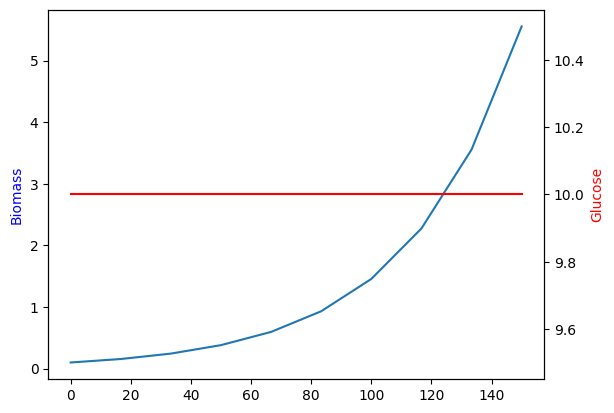

In [158]:
ax = plt.subplot(111)
ax.plot(sol.t, sol.y.T[:, 0])
ax2 = plt.twinx(ax)
ax2.plot(sol.t, sol.y.T[:, 1], color='r')

ax.set_ylabel('Biomass', color='b')
ax2.set_ylabel('Glucose', color='r')

## Clostridium model


In [204]:
# untar model 
model = read_sbml_model('../data/models/MODEL1507180034_url.xml')
#  Print basic model information
print("Model Details:")
print(f"Number of reactions: {len(model.reactions)}")
print(f"Number of metabolites: {len(model.metabolites)}")
print(f"Number of genes: {len(model.genes)}")

print("________________________________________")

# 1. Print the current objective function directly
print("Current objective:", model.objective.expression, "\n")

# 2. Get all reactions that are part of the objective
for reaction in model.objective.variables:
    print(f"Reaction Name: {reaction.name}")


    # if 'glucose' in metabolite.name.lower() or 'glc' in metabolite.id.lower():
tracked_metabolites = [met for met in model.metabolites if "h2" in met.name.lower() or "glc" in met.id.lower() or "hydrogen" in met.name.lower()]
tracked_metabolites_external = [met for met in tracked_metabolites if "_e" in met.id]

print("\n")
print("Interesting metabolites:")
for met in tracked_metabolites_external:
    print(f"{met.name} ({met.id} {met.formula})")


Model Details:
Number of reactions: 938
Number of metabolites: 881
Number of genes: 926
________________________________________
Current objective: 1.0*biomass - 1.0*biomass_reverse_01e59 

Reaction Name: biomass
Reaction Name: biomass_reverse_01e59


Interesting metabolites:
2ddglcn[e] (2ddglcn_e C6H9O6)
glc-D[e] (glc_D_e C6H12O6)
glcn[e] (glcn_e C6H11O7)
h2[e] (h2_e H2)
h2o[e] (h2o_e H2O)


Here, the relevant metabolites will be, as input, the Hydrogen (h2_e), the CO2 (co2_e), and as output, the methane (ch4s_c)

In [205]:
# 3. See what the objective function is
print("\nObjective function:")
print(model.objective.expression)

# 4. Run a simple FBA
solution = model.optimize()
print(f"\nGrowth rate: {solution.objective_value:.4f}")

# 5. Look at some key exchange reactions
print("\n")
print(f"\nRelevant fluxes: {[m.id for m in tracked_metabolites_external]}")
print("===============================")

for reaction in model.reactions:
    reaction_metabolites = [m.id for m in reaction.metabolites]
    # external carbon source (glucose or gluconate)
    glc_metabolites = [m for m in reaction_metabolites if m in [m.id for m in tracked_metabolites_external]]
    # print(reaction.__dict__.keys())
    if len(glc_metabolites) > 0:  # Exchange reactions usually start with EX_
        flux = solution.fluxes[reaction.id]
        print(f"ID: {reaction.id}, Flux: {flux:.4f}")
        print(f"{reaction.reaction}")
        print(f"Reaction genes: {[f'{g.id} ({g.name})' for g in reaction.genes]}")
        print(f"Reaction metabolites: {[f'name: {m.name}, id: {m.id}' for m in reaction.metabolites]}")
        print("================================================")


Objective function:
1.0*biomass - 1.0*biomass_reverse_01e59

Growth rate: 0.1194



Relevant fluxes: ['2ddglcn_e', 'glc_D_e', 'glcn_e', 'h2_e', 'h2o_e']
ID: 2DDGLCNex, Flux: 0.0000
2ddglcn_e + h_e --> 2ddglcn_c + h_c
Reaction genes: ['Cbei_2459 (Cbei_2459)', 'Cbei_4007 (Cbei_4007)']
Reaction metabolites: ['name: 2ddglcn[e], id: 2ddglcn_e', 'name: h[e], id: h_e', 'name: 2ddglcn[c], id: 2ddglcn_c', 'name: h[c], id: h_c']
ID: GLCNex, Flux: 0.0000
glcn_e --> glcn_c
Reaction genes: ['Cbei_4480 (Cbei_4480)']
Reaction metabolites: ['name: glcn[e], id: glcn_e', 'name: glcn[c], id: glcn_c']
ID: GLCabc, Flux: 0.0000
atp_c + glc_D_e + h2o_c --> adp_c + glc_D_c + h_c + pi_c
Reaction genes: []
Reaction metabolites: ['name: atp[c], id: atp_c', 'name: glc-D[e], id: glc_D_e', 'name: h2o[c], id: h2o_c', 'name: adp[c], id: adp_c', 'name: glc-D[c], id: glc_D_c', 'name: h[c], id: h_c', 'name: pi[c], id: pi_c']
ID: GLCpts, Flux: 2.6900
glc_D_e + pep_c --> g6p_c + pyr_c
Reaction genes: ['Cbei_4706 (Cbei_47